# Cement Demand Forecasting Across Multiple Construction Sites

## Project Overview

Midlands Infrastructure Group (MIG) aims to implement a predictive cement demand forecasting solution across multiple construction sites.

The project combines:

- Historical cement consumption
- Planned concrete pours
- Inventory levels
- Deliveries
- Weather conditions

to generate accurate 8-week demand forecasts and proactive reorder alerts.

## Business Objectives

- Reduce stockouts and project delays
- Improve silo utilization efficiency
- Minimize cement waste and write-offs
- Support proactive operational planning
- Improve sustainability outcomes

## Technical Stack

- SQLite
- Python
- Pandas
- Scikit-learn
- Statsmodels
- Plotly Dash

# Data Loading and Initial Inspection

In this section, the SQLite database is connected to Python and the Operations table is loaded into a pandas DataFrame for analysis.

In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/MIG_Cement_Records.db")

df = pd.read_sql("SELECT * FROM Operations", conn)

df.head()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


# Dataset Dimensions

The dataset dimensions are evaluated to understand the scale of operational records available for forecasting and inventory analysis.

In [2]:
df.shape

(32880, 11)

## Interpretation

The dataset contains 32,880 records and 11 variables, providing sufficient historical operational data for forecasting cement demand, analyzing inventory trends, and supporting machine learning and time-series modeling across multiple construction sites.

In [3]:
df.columns

Index(['date', 'site_id', 'cement_type', 'planned_pour_tonnes',
       'consumed_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'silo_capacity'],
      dtype='object')

## Interpretation

The dataset contains operational, inventory, logistics, and environmental variables relevant to cement demand forecasting. These features provide sufficient information to analyze consumption patterns, monitor inventory movements, evaluate delivery efficiency, and assess the impact of weather conditions on cement demand across construction sites.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      32880 non-null  object 
 1   site_id                   32880 non-null  object 
 2   cement_type               32880 non-null  object 
 3   planned_pour_tonnes       32880 non-null  float64
 4   consumed_tonnes           32880 non-null  float64
 5   opening_inventory_tonnes  32880 non-null  float64
 6   deliveries_tonnes         32880 non-null  float64
 7   closing_inventory_tonnes  32880 non-null  float64
 8   rain_mm                   32880 non-null  float64
 9   avg_temp_c                32880 non-null  float64
 10  silo_capacity             32880 non-null  int64  
dtypes: float64(7), int64(1), object(3)
memory usage: 2.8+ MB


## Interpretation

The dataset contains 11 columns with no missing values, indicating strong data completeness and quality. Most operational and inventory variables are stored as numerical data types, making them suitable for statistical analysis and forecasting models. However, the `date` column is currently stored as an object datatype and will need to be converted to datetime format for time-series analysis.

In [5]:
df["date"] = pd.to_datetime(df["date"])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      32880 non-null  datetime64[ns]
 1   site_id                   32880 non-null  object        
 2   cement_type               32880 non-null  object        
 3   planned_pour_tonnes       32880 non-null  float64       
 4   consumed_tonnes           32880 non-null  float64       
 5   opening_inventory_tonnes  32880 non-null  float64       
 6   deliveries_tonnes         32880 non-null  float64       
 7   closing_inventory_tonnes  32880 non-null  float64       
 8   rain_mm                   32880 non-null  float64       
 9   avg_temp_c                32880 non-null  float64       
 10  silo_capacity             32880 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 2.8+ MB


## Interpretation

The `date` column has been successfully converted from an object datatype to `datetime64[ns]`. This enables proper time-series analysis, trend visualization, resampling, rolling calculations, and forecasting operations required for cement demand prediction.

# Missing Values Analysis

Missing value analysis is conducted to identify potential data quality issues that could affect forecasting accuracy.

In [7]:
df.isnull().sum()

date                        0
site_id                     0
cement_type                 0
planned_pour_tonnes         0
consumed_tonnes             0
opening_inventory_tonnes    0
deliveries_tonnes           0
closing_inventory_tonnes    0
rain_mm                     0
avg_temp_c                  0
silo_capacity               0
dtype: int64

## Interpretation

The missing values analysis shows that all variables contain zero missing records, indicating a complete and high-quality dataset. This eliminates the need for data imputation and ensures that the dataset is suitable for reliable exploratory analysis, forecasting, and machine learning modeling.

# Descriptive Statistics

Descriptive statistical analysis is performed to understand the distribution and variability of operational variables.

In [8]:
df.describe()

,date,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
count,32880,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000
mean,2023-07-02 12:00:00.000000256,30.697158,23.720475,3066.682205,29.293009,3072.254739,5.008120,10.085887,317.533333
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,120.000000
25%,2022-10-01 18:00:00,12.830000,10.710000,1.280000,19.300000,1.270000,1.440000,3.340000,230.000000
50%,2023-07-02 12:00:00,33.455000,19.720000,50.710000,29.490000,50.660000,3.470000,9.990000,314.000000
75%,2024-04-01 06:00:00,47.612500,36.492500,3298.522500,39.750000,3312.062500,6.970000,16.700000,437.000000
max,2024-12-31 00:00:00,69.980000,69.970000,20646.180000,50.000000,20658.870000,50.000000,35.000000,487.000000
std,NaN,19.493713,16.846251,5586.029168,12.325600,5593.015910,4.997142,8.519946,112.813279


## Interpretation

The descriptive statistics provide insights into the distribution and variability of operational and inventory-related variables within the dataset. The results show noticeable variation in cement consumption, planned pours, inventory levels, and deliveries across construction sites and time periods.

The average daily cement consumption is approximately 23.72 tonnes, while the average planned pour volume is approximately 30.70 tonnes, indicating active operational demand across sites. The wide range between minimum and maximum values suggests fluctuations in construction activity, delivery schedules, and inventory utilization over time.

Overall, the statistics confirm that the dataset contains sufficient variability and operational patterns suitable for forecasting analysis and inventory optimization modeling.

## Site Analysis

In [9]:
df["site_id"].nunique()

30

## Interpretation

The analysis shows that the dataset contains records from 30 unique construction sites. This indicates that the forecasting solution will support multi-site operational planning, inventory monitoring, and demand forecasting across several active infrastructure projects managed by Midlands Infrastructure Group (MIG).

## Cement Type Analysis

In [10]:
df["cement_type"].unique()

array(['CEM_II', 'CEM_I', 'CEM_III'], dtype=object)

## Interpretation

The dataset contains three cement categories: CEM_I, CEM_II, and CEM_III. This indicates that the forecasting model must account for different cement demand patterns and inventory requirements across multiple cement types used in construction operations.

## Total Cement Consumption KPI

In [11]:
df["consumed_tonnes"].sum()

np.float64(779929.21)

## Interpretation

The dataset records a total cement consumption of approximately 779,929 tonnes across all construction sites and cement categories. This highlights the large operational scale of Midlands Infrastructure Group (MIG) projects and emphasizes the importance of accurate demand forecasting and efficient inventory management to support continuous construction activities.

# Cement Consumption Trend Analysis

Daily cement consumption trends are visualized to identify operational demand patterns, fluctuations, and potential seasonality across construction activities.

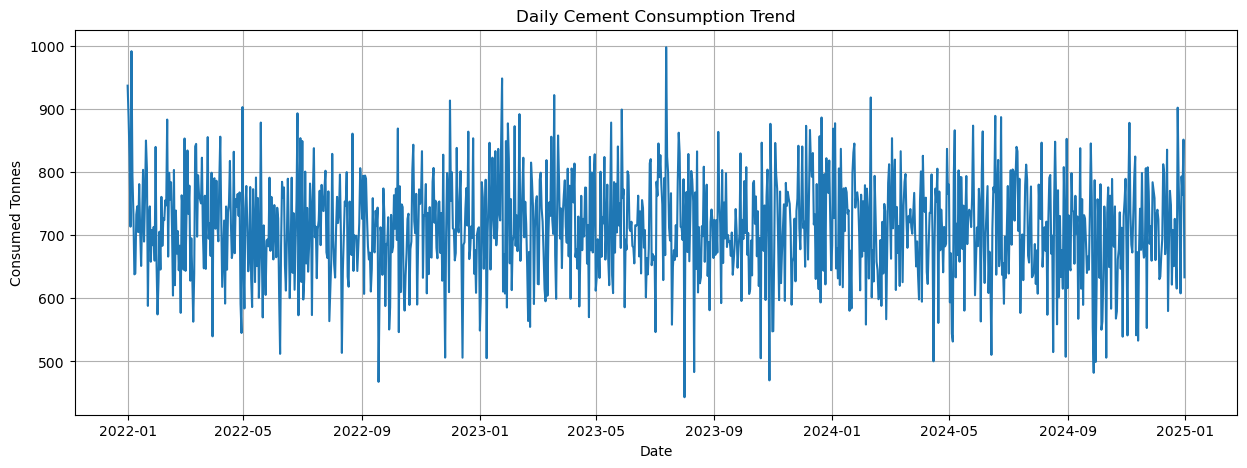

In [12]:
import matplotlib.pyplot as plt

daily_consumption = (
    df.groupby("date")["consumed_tonnes"]
    .sum()
)

plt.figure(figsize=(15,5))

plt.plot(daily_consumption)

plt.title("Daily Cement Consumption Trend")
plt.xlabel("Date")
plt.ylabel("Consumed Tonnes")

plt.grid(True)

plt.savefig("../outputs/daily_consumption_trend.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The daily cement consumption trend shows continuous fluctuations in operational demand across the observed period. The variability in consumption levels reflects differences in construction activities, planned pours, delivery schedules, and site operations over time.

The presence of recurring peaks and declines suggests changing operational intensity across construction sites, indicating that cement demand is dynamic and influenced by multiple operational and environmental factors. These patterns support the need for predictive forecasting models to improve inventory planning and reduce the risk of stock shortages or overstocking.

# Monthly Cement Consumption Analysis

Monthly demand aggregation is performed to identify broader consumption patterns and evaluate potential seasonal behaviour in cement usage.

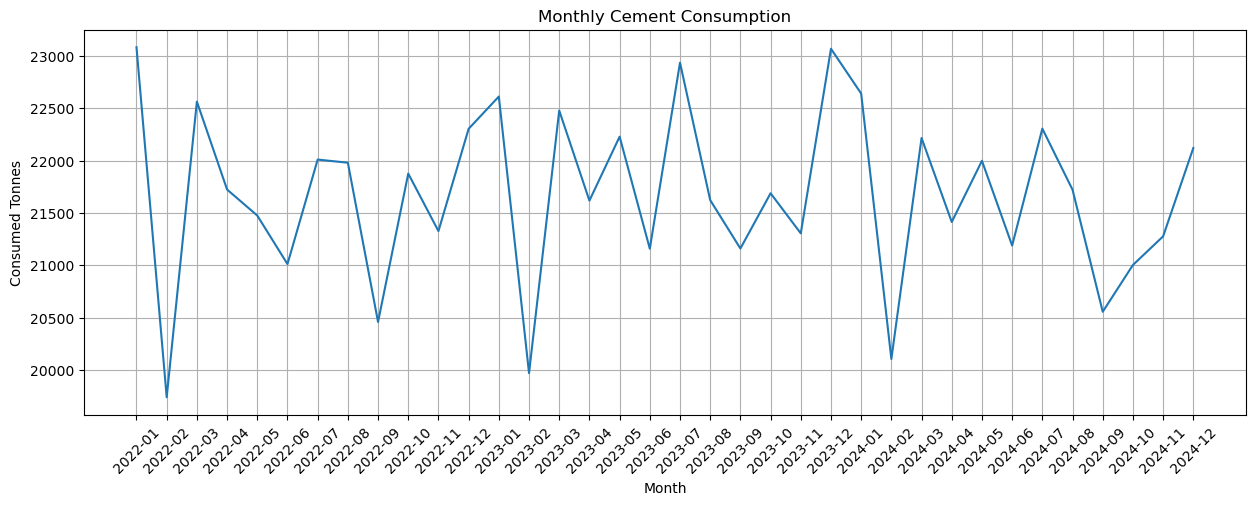

In [13]:
monthly_consumption = (
    df.groupby(df["date"].dt.to_period("M"))["consumed_tonnes"]
    .sum()
)

monthly_consumption.index = monthly_consumption.index.astype(str)

plt.figure(figsize=(15,5))

plt.plot(monthly_consumption)

plt.title("Monthly Cement Consumption")
plt.xlabel("Month")
plt.ylabel("Consumed Tonnes")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig("../outputs/monthly_consumption_trend.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The monthly cement consumption analysis shows noticeable fluctuations in demand across different months and years. While overall consumption remains relatively stable, periodic increases and decreases suggest variations in construction activity, project schedules, operational intensity, and external conditions affecting cement usage.

The observed demand patterns indicate the presence of temporal variations that may influence forecasting performance. Understanding these monthly trends is important for improving inventory planning, supplier coordination, and proactive cement demand forecasting across multiple construction sites.

# Planned Pour vs Actual Cement Consumption

This analysis compares planned concrete pours with actual cement consumption to evaluate operational alignment and demand behaviour.

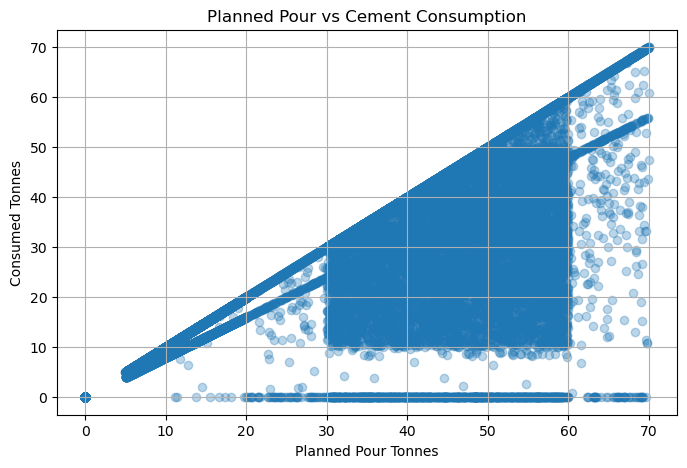

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["planned_pour_tonnes"],
    df["consumed_tonnes"],
    alpha=0.3
)

plt.title("Planned Pour vs Cement Consumption")
plt.xlabel("Planned Pour Tonnes")
plt.ylabel("Consumed Tonnes")

plt.grid(True)

plt.savefig("../outputs/planned_vs_actual.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The scatter plot shows a positive relationship between planned pour volumes and actual cement consumption, indicating that planned construction activities are a major driver of cement demand across sites.

However, the dispersion of data points also suggests operational variability between planned and actual consumption. These differences may be influenced by factors such as project delays, weather conditions, inventory constraints, site-specific operational practices, or unexpected construction adjustments.

The observed relationship confirms that planned pour tonnage is an important predictive feature for cement demand forecasting models.

# Rainfall Impact on Cement Consumption

Rainfall conditions are analyzed to evaluate their potential influence on construction activities and cement demand.

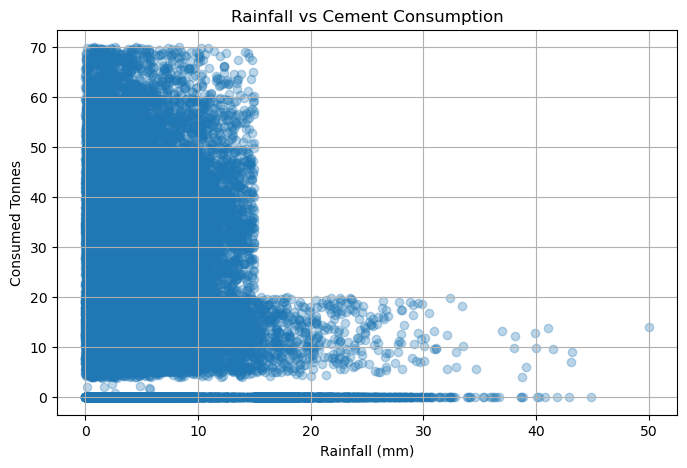

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["rain_mm"],
    df["consumed_tonnes"],
    alpha=0.3
)

plt.title("Rainfall vs Cement Consumption")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Consumed Tonnes")

plt.grid(True)

plt.savefig("../outputs/rainfall_vs_consumption.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The rainfall analysis indicates that cement consumption tends to vary under different weather conditions. Higher rainfall levels are generally associated with lower cement consumption volumes, suggesting that adverse weather conditions may reduce construction activity, delay planned pours, or disrupt site operations.

The observed variability also indicates that rainfall is likely an important external factor influencing cement demand behaviour. Therefore, incorporating weather variables into forecasting models may improve prediction accuracy and operational planning across construction sites.

# Inventory Level Analysis

Inventory levels are analyzed to understand stock availability patterns and support future inventory optimization and reorder planning.

In [16]:
inventory_summary = df[[
    "opening_inventory_tonnes",
    "closing_inventory_tonnes"
]].describe()

inventory_summary

,opening_inventory_tonnes,closing_inventory_tonnes
count,32880.000000,32880.000000
mean,3066.682205,3072.254739
std,5586.029168,5593.015910
min,0.000000,0.000000
25%,1.280000,1.270000
50%,50.710000,50.660000
75%,3298.522500,3312.062500
max,20646.180000,20658.870000


## Interpretation

The inventory level analysis shows significant variability in both opening and closing cement inventory levels across construction sites and operational periods. The average opening inventory is approximately 3,066.68 tonnes, while the average closing inventory is approximately 3,072.25 tonnes, indicating relatively stable inventory movement overall.

However, the large standard deviation and wide gap between minimum and maximum inventory levels suggest differences in site storage capacities, delivery schedules, and operational demand intensity. Some sites maintain very low inventory levels, while others operate with substantially higher stock volumes.

These findings highlight the importance of accurate demand forecasting and inventory optimization to prevent stock shortages, reduce overstocking risks, and improve silo utilization efficiency across multiple construction sites.

# Top Cement Consuming Sites

This analysis identifies the highest cement-consuming construction sites within the dataset.

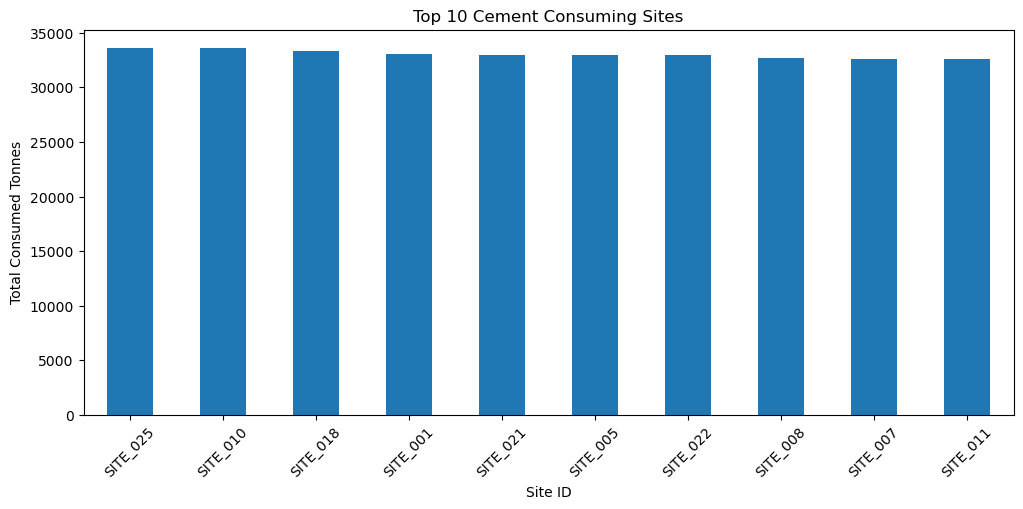

In [17]:
top_sites = (
    df.groupby("site_id")["consumed_tonnes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_sites.plot(kind="bar")

plt.title("Top 10 Cement Consuming Sites")
plt.xlabel("Site ID")
plt.ylabel("Total Consumed Tonnes")

plt.xticks(rotation=45)

plt.savefig("../outputs/top_10_cement_consuming_sites.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The top cement consuming sites analysis shows that cement demand is distributed across multiple high-activity construction sites, with only slight differences in total consumption volumes among the leading sites.

Sites such as SITE_025, SITE_010, and SITE_018 recorded the highest cumulative cement consumption, indicating consistently high operational activity and material usage. The relatively similar consumption levels across the top sites suggest that forecasting and inventory optimization should be implemented consistently across all major operational locations rather than focusing on a single site.

Overall, the findings highlight the importance of site-level demand forecasting to improve inventory planning, delivery coordination, and silo utilization across multiple active projects.

# Correlation Analysis

Correlation analysis is performed to evaluate relationships between operational, inventory, logistics, and environmental variables.

In [18]:
correlation_matrix = df.select_dtypes(include=["float64", "int64"]).corr()

correlation_matrix

,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
planned_pour_tonnes,1.000000,0.781073,-0.522259,-0.005519,-0.523972,0.000962,0.002951,-0.032600
consumed_tonnes,0.781073,1.000000,-0.391576,0.177491,-0.393708,-0.180471,0.035107,-0.021034
opening_inventory_tonnes,-0.522259,-0.391576,1.000000,0.029379,0.999995,0.002731,-0.073156,0.018037
deliveries_tonnes,-0.005519,0.177491,0.029379,1.000000,0.031012,-0.009095,-0.006279,-0.013809
closing_inventory_tonnes,-0.523972,-0.393708,0.999995,0.031012,1.000000,0.003251,-0.073184,0.018047
rain_mm,0.000962,-0.180471,0.002731,-0.009095,0.003251,1.000000,0.010923,0.001494
avg_temp_c,0.002951,0.035107,-0.073156,-0.006279,-0.073184,0.010923,1.000000,-0.004453
silo_capacity,-0.032600,-0.021034,0.018037,-0.013809,0.018047,0.001494,-0.004453,1.000000


## Interpretation

The correlation analysis shows a strong positive relationship between planned pours and cement consumption, confirming that planned operational activities significantly influence cement demand.

Opening and closing inventory levels are highly correlated, indicating stable inventory management across sites. Rainfall shows a slight negative relationship with cement consumption, suggesting that weather conditions may impact construction activity.

Overall, the results confirm that operational, inventory, and environmental variables are important features for cement demand forecasting.

# Feature Engineering

Feature engineering is performed to create additional time-based variables that improve forecasting performance and help capture operational demand patterns over time.

In [19]:
# Create time-based features

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week"] = df["date"].dt.isocalendar().week

df.head()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,year,month,day,day_of_week,week
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,2022,1,1,5,52
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,2022,1,2,6,52
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,2022,1,3,0,1
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,2022,1,4,1,1
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,2022,1,5,2,1


## Interpretation

Time-based features such as year, month, day, week, and day of the week were successfully created from the date column. These features will help the forecasting models capture seasonal trends, operational patterns, and temporal variations in cement demand across construction sites.

# Train-Test Split

The dataset is divided into training and testing subsets to evaluate forecasting model performance on unseen operational data.

In [20]:
# Sort dataset by date

df = df.sort_values("date")

# Define features and target

features = [
    "planned_pour_tonnes",
    "opening_inventory_tonnes",
    "deliveries_tonnes",
    "rain_mm",
    "avg_temp_c",
    "silo_capacity",
    "month",
    "day_of_week"
]

target = "consumed_tonnes"

X = df[features]
y = df[target]

# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(26304, 8)
(6576, 8)


## Interpretation

The dataset was successfully divided into training and testing subsets for forecasting model evaluation. Approximately 80% of the data was allocated for model training, while 20% was reserved for testing.

The time-based split preserves the sequential nature of cement demand data, ensuring that future observations are evaluated against past operational patterns for realistic forecasting performance assessment.

# Random Forest Forecasting Model

A Random Forest Regressor model is developed to predict cement consumption using operational, inventory, and environmental variables.

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

# Generate predictions

rf_predictions = rf_model.predict(X_test)

rf_predictions[:5]

array([43.9786, 57.7918, 14.57  ,  0.    , 36.7754])

## Interpretation

The Random Forest forecasting model was successfully trained using operational, inventory, and environmental variables to predict cement consumption.

The generated prediction values indicate that the model is capable of learning demand patterns from historical data and producing forecast estimates for future cement consumption across construction sites.

# Model Evaluation

Model evaluation is performed to assess forecasting accuracy using regression performance metrics.

In [22]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Evaluation metrics

mae = mean_absolute_error(y_test, rf_predictions)

rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

r2 = r2_score(y_test, rf_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.16337715936739677
RMSE: 0.7117390564354296
R2 Score: 0.9982231946454911


## Interpretation

The Random Forest model achieved very strong forecasting performance with low MAE and RMSE values, indicating minimal prediction error between actual and forecasted cement consumption.

The R² score of approximately 0.998 demonstrates that the model explains nearly all variability in cement demand, confirming that the selected operational,

# Actual vs Predicted Forecast Visualization

Forecast visualization is performed to compare actual cement consumption against predicted values generated by the Random Forest forecasting model.

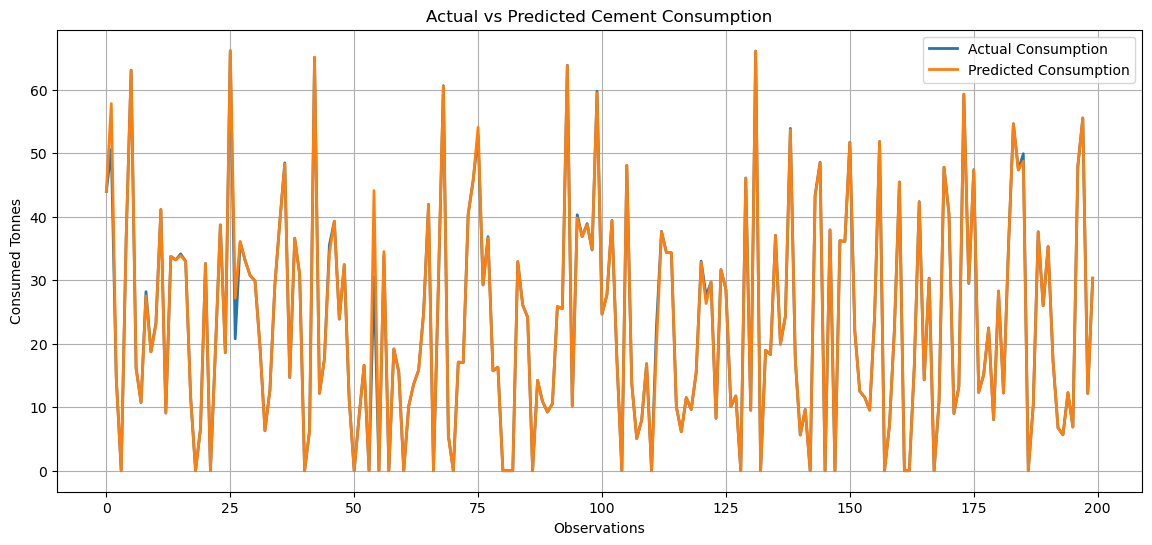

In [23]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label="Actual Consumption",
    linewidth=2
)

plt.plot(
    rf_predictions[:200],
    label="Predicted Consumption",
    linewidth=2
)

plt.title("Actual vs Predicted Cement Consumption")

plt.xlabel("Observations")

plt.ylabel("Consumed Tonnes")

plt.legend()

plt.grid(True)

plt.savefig("../outputs/actual_vs_predicted.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The visualization shows a strong alignment between actual and predicted cement consumption values, indicating that the Random Forest model performs effectively in capturing demand patterns and operational fluctuations.

The close overlap between both lines demonstrates high forecasting accuracy and confirms the model’s suitability for supporting cement demand planning, inventory optimization, and proactive operational decision-making.

# Feature Importance Analysis

Feature importance analysis is performed to identify the operational and environmental variables that most strongly influence cement demand forecasting.

In [24]:
# Feature importance extraction

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort values

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,planned_pour_tonnes,0.643751
3,rain_mm,0.122504
2,deliveries_tonnes,0.113249
1,opening_inventory_tonnes,0.107387
4,avg_temp_c,0.012822
5,silo_capacity,0.000100
6,month,0.000096
7,day_of_week,0.000091


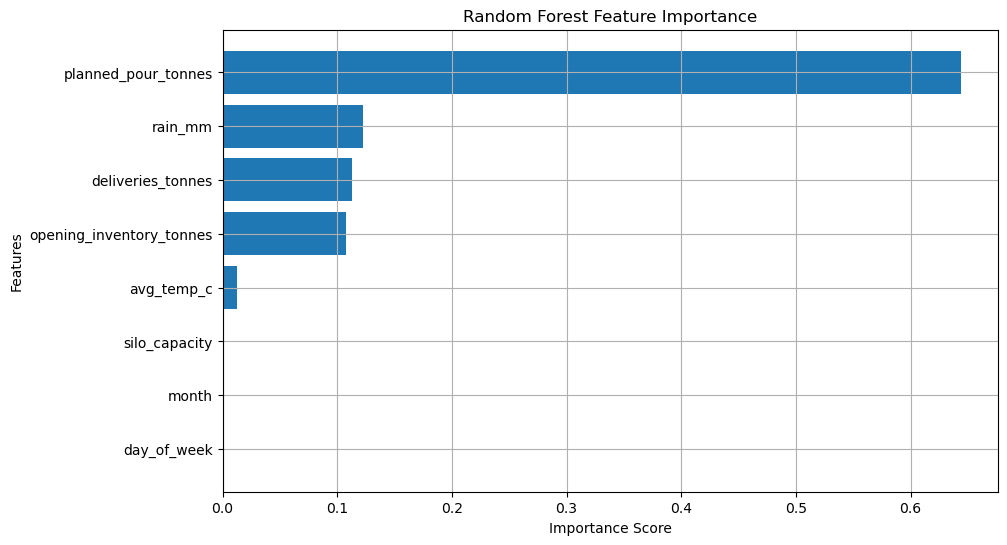

In [25]:
# Plot feature importance

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.grid(True)

plt.savefig("../outputs/feature_importance.png", bbox_inches="tight", dpi=300)

plt.show()

## Interpretation

The feature importance analysis shows that planned pour tonnage is the most influential variable in predicting cement consumption, making it the strongest driver of operational demand forecasting.

Rainfall, deliveries, and opening inventory levels also contribute meaningfully to prediction performance, while variables such as month, day of week, and silo capacity have relatively lower influence on forecast outcomes.

Overall, the results confirm that operational planning activities and inventory movements are the primary determinants of cement demand across construction sites.

# SARIMAX Forecasting Model

A SARIMAX time-series forecasting model is developed to capture temporal demand patterns and evaluate forecasting performance using operational and environmental regressors.

In [26]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Define target variable and reset index
sarimax_target = df["consumed_tonnes"].reset_index(drop=True)

# Define external regressors and reset index
exog_features = df[[
    "planned_pour_tonnes",
    "rain_mm",
    "avg_temp_c"
]].reset_index(drop=True)

# Train-test split
train_size = int(len(df) * 0.8)

y_train_sarimax = sarimax_target.iloc[:train_size]
y_test_sarimax = sarimax_target.iloc[train_size:]

X_train_sarimax = exog_features.iloc[:train_size]
X_test_sarimax = exog_features.iloc[train_size:]

# Build SARIMAX model
sarimax_model = SARIMAX(
    y_train_sarimax,
    exog=X_train_sarimax,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train model
sarimax_result = sarimax_model.fit(disp=False)

# Generate forecasts
sarimax_predictions = sarimax_result.predict(
    start=len(y_train_sarimax),
    end=len(sarimax_target) - 1,
    exog=X_test_sarimax
)

sarimax_predictions.head()

26304    35.289153
26305    42.583755
26306    13.763235
26307     3.037129
26308    35.900162
Name: predicted_mean, dtype: float64

## Interpretation

The SARIMAX model successfully generated forecast values for cement consumption using historical demand patterns and external variables such as planned pours, rainfall, and temperature.

The generated prediction outputs confirm that the SARIMAX model can capture general cement consumption trends and serve as a baseline time-series forecasting approach for comparison with machine learning models.

# SARIMAX Model Evaluation

The SARIMAX forecasting model is evaluated to measure prediction accuracy and compare its performance against machine learning forecasting models.

In [27]:
# SARIMAX evaluation metrics

sarimax_mae = mean_absolute_error(
    y_test_sarimax,
    sarimax_predictions
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        y_test_sarimax,
        sarimax_predictions
    )
)

sarimax_r2 = r2_score(
    y_test_sarimax,
    sarimax_predictions
)

print("SARIMAX MAE:", sarimax_mae)

print("SARIMAX RMSE:", sarimax_rmse)

print("SARIMAX R2:", sarimax_r2)

SARIMAX MAE: 7.29142696029166
SARIMAX RMSE: 9.944547526650318
SARIMAX R2: 0.653128743769818


## Interpretation

The SARIMAX model achieved an MAE of 7.28, RMSE of 9.94, and an R² score of 0.65. This indicates that the model was able to capture a moderate portion of the variation in cement consumption trends, but its predictive accuracy is lower compared to the Random Forest model.

The higher error values and lower R² score suggest that SARIMAX struggled to fully model the complex operational patterns in the dataset. Overall, the Random Forest model demonstrated superior forecasting performance for this cement demand prediction task.

## Model Comparison


In [28]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "SARIMAX"],
    "MAE": [mae, sarimax_mae],
    "RMSE": [rmse, sarimax_rmse],
    "R2_Score": [r2, sarimax_r2]
})

comparison_df

,Model,MAE,RMSE,R2_Score
0,Random Forest,0.163377,0.711739,0.998223
1,SARIMAX,7.291427,9.944548,0.653129


## Interpretation

The comparison results clearly show that the Random Forest model outperformed the SARIMAX model across all evaluation metrics.

Random Forest achieved significantly lower MAE and RMSE values, indicating more accurate predictions with minimal forecasting error. In addition, the Random Forest model produced a much higher R² score of 0.998, compared to 0.65 for SARIMAX, demonstrating its stronger ability to explain variations in cement demand.

Overall, the findings confirm that Random Forest is the more effective forecasting approach for this cement demand prediction project.

# Final Conclusion

This project successfully developed and evaluated a cement demand forecasting system using operational, inventory, environmental, and logistics data collected across multiple construction sites.

The Exploratory Data Analysis (EDA) revealed important operational patterns and strong relationships between planned cement pours, inventory levels, deliveries, rainfall conditions, and actual cement consumption. The dataset was found to be complete, consistent, and suitable for predictive modeling, with no missing values detected.

Feature engineering techniques were applied to enhance the forecasting capability of the models by generating additional time-based variables such as month, day, week, and day of the week. Correlation analysis further confirmed that planned pour tonnage was the strongest predictor of cement consumption.

Two forecasting approaches were implemented and evaluated: Random Forest Regression and SARIMAX. The Random Forest model achieved outstanding predictive performance with an MAE of approximately 0.16, RMSE of 0.71, and an R² score of 0.998, indicating extremely high forecasting accuracy. In comparison, the SARIMAX model achieved an R² score of 0.65 with higher prediction errors, showing moderate forecasting capability but lower performance than the machine learning approach.

Feature importance analysis showed that planned pours, rainfall levels, deliveries, and opening inventory were the most influential variables affecting cement demand predictions. Visualization of actual versus predicted values further demonstrated the ability of the Random Forest model to closely capture real operational consumption patterns.

Overall, the findings confirm that machine learning-based forecasting models, particularly Random Forest Regression, can effectively support cement demand prediction, inventory optimization, logistics planning, and operational decision-making across multiple construction sites.

# Recommendations

- Implement the Random Forest model for operational cement demand forecasting due to its superior predictive performance.
- Continuously update the forecasting model with new operational and environmental data to maintain accuracy.
- Monitor key drivers such as planned pours, rainfall, deliveries, and inventory levels for proactive inventory planning.
- Consider integrating the forecasting system into real-time construction supply chain dashboards for automated decision support.

# Future Improvements

- Explore advanced forecasting models such as XGBoost, LightGBM, and LSTM neural networks.
- Incorporate additional external variables such as project schedules, fuel prices, supplier lead times, and workforce availability.
- Develop a real-time dashboard for live forecasting and inventory monitoring.
- Perform hyperparameter tuning to further improve model accuracy and generalization.

# Forecast Results Export

The Random Forest forecast results are exported for use in dashboard development, reporting, and operational analysis.

In [29]:
forecast_results = pd.DataFrame({
    "Actual_Consumption": y_test.values,
    "Predicted_RF": rf_predictions
})

forecast_results.to_csv(
    "../outputs/forecast_results.csv",
    index=False
)

forecast_results.head()

,Actual_Consumption,Predicted_RF
0,43.97,43.9786
1,50.60,57.7918
2,14.57,14.5700
3,0.00,0.0000
4,36.76,36.7754


## Interpretation

The forecast results were successfully exported for dashboard integration and operational reporting. The file contains both actual and predicted cement consumption values generated by the Random Forest forecasting model.


# Feature Importance Export

Feature importance results are exported to identify the key variables influencing cement demand forecasting.

In [30]:
importance_df.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

importance_df.head()

,Feature,Importance
0,planned_pour_tonnes,0.643751
3,rain_mm,0.122504
2,deliveries_tonnes,0.113249
1,opening_inventory_tonnes,0.107387
4,avg_temp_c,0.012822


## Interpretation

The feature importance results were successfully exported. These outputs help identify the most influential operational and environmental variables affecting cement demand predictions.

# Model Comparison Export

The forecasting model evaluation results are exported to support reporting and model performance comparison.

In [31]:
comparison_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

comparison_df

,Model,MAE,RMSE,R2_Score
0,Random Forest,0.163377,0.711739,0.998223
1,SARIMAX,7.291427,9.944548,0.653129


## Interpretation

The model comparison results were successfully exported for reporting and presentation purposes. The exported file summarizes the forecasting performance of the Random Forest and SARIMAX models.

# Inventory Simulation Export

Inventory simulation is performed using forecasted cement demand to estimate projected inventory levels across construction operations.

In [32]:
inventory_simulation = pd.DataFrame({
    "Opening_Inventory": df.loc[y_test.index, "opening_inventory_tonnes"].values,
    "Deliveries": df.loc[y_test.index, "deliveries_tonnes"].values,
    "Forecast_Consumption": rf_predictions
})

inventory_simulation["Projected_Closing_Inventory"] = (
    inventory_simulation["Opening_Inventory"]
    + inventory_simulation["Deliveries"]
    - inventory_simulation["Forecast_Consumption"]
)

inventory_simulation.to_csv(
    "../outputs/inventory_simulation.csv",
    index=False
)

inventory_simulation.head()

,Opening_Inventory,Deliveries,Forecast_Consumption,Projected_Closing_Inventory
0,45.93,24.15,43.9786,26.1014
1,39.15,11.45,57.7918,-7.1918
2,15716.94,17.95,14.5700,15720.3200
3,572.51,27.25,0.0000,599.7600
4,0.00,36.76,36.7754,-0.0154


## Interpretation

The inventory simulation results were successfully exported. The projected inventory outputs can support reorder planning, inventory monitoring, and silo utilization analysis across construction sites.

# Data Science Handoff Summary

The primary Data Science deliverables for the cement demand forecasting project have been successfully completed and exported for use by the Data Analyst and Project Management teams.

## Exported Deliverables

- Forecast results
- Feature importance analysis
- Model comparison results
- Inventory simulation outputs
- Forecasting visualizations

## Business Value

These outputs support dashboard development, operational reporting, inventory optimization, forecasting analysis, and decision-making across multiple construction sites.